<a href="https://colab.research.google.com/github/roshan-mahato/PRT_661_WILDFIRE_PREDICTION/blob/feature%2Fcomponents/ML_Model_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wildfire Fire-Occurrence Classifier — Final Model Training & Accuracy Improvement

## Modelling objective

The target is **`label`**:

- `1` = fire occurred / a qualifying fire detection was recorded for that grid-cell/day
- `0` = sampled no-fire grid-cell/day

This is a **binary classification** problem.

### Model inputs (`X`)
Only variables that can be generated from weather and the fire-weather feature-engineering pipeline are used. These include temperature, humidity, wind, precipitation, soil moisture, KBDI, Drought Factor, EMC and FFDI.

Satellite detection fields such as brightness, confidence, FRP, type, satellite and instrument are **not model inputs**. They are historical evidence used to create/validate the target label, not information the deployed prediction model should require.

### Outputs
The final classifier returns:

1. a **model fire-risk score** from `predict_proba()`; and
2. a **binary fire/no-fire prediction** using a validation-selected threshold.

> The score is useful for the dashboard/heatmap, but it should not be described as a calibrated real-world probability until probability calibration has been separately validated.

## 1. Setup

Run the install line once in Google Colab if the packages are not already available.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# In Google Colab, uncomment if needed:
# !pip -q install xgboost lightgbm joblib

import os
import json
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve
)

import xgboost as xgb
import lightgbm as lgb

RANDOM_STATE = 42
OUT_DIR = Path('/content/drive/MyDrive/fire_model_outputs')
OUT_DIR.mkdir(parents=True, exist_ok=True)


## 2. Load `final_df`

The preferred input is the final labelled dataframe produced by the preprocessing and feature-engineering stage.

If this modelling section is appended to the same notebook and `final_df` already exists, it is used directly. Otherwise the code searches common saved CSV locations. Change `FINAL_CSV` only if your file is stored somewhere else.

In [3]:
# Mount Google Drive when running in Colab
from pathlib import Path

if not Path('/content/drive/MyDrive').exists():
    from google.colab import drive
    drive.mount('/content/drive')
else:
    print("Google Drive is already mounted.")

FINAL_CSV = '/content/drive/MyDrive/firms_weather_cleaned_with_negatives.csv'

assert Path(FINAL_CSV).exists(), (
    f'File not found: {FINAL_CSV}'
)

print('Loading:', FINAL_CSV)

df = pd.read_csv(FINAL_CSV)

print('Raw modelling dataframe shape:', df.shape)
display(df.head())

Google Drive is already mounted.
Loading: /content/drive/MyDrive/firms_weather_cleaned_with_negatives.csv
Raw modelling dataframe shape: (209793, 22)


,lat_round,lon_round,acq_date,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_gusts_10m,wind_direction_10m,precipitation,soil_moisture_0_to_7cm,...,label,weather_outlier_flag,kbdi,drought_factor,days_since_rain,days_since_cell_start,kbdi_spinup_flag,emc,ffdi,rate_of_spread
0,-43.5,146.0,2024-05-10,12.410222,81.477038,8.248152,17.655999,105.361071,0.0,0.229356,...,1,False,0.201304,5.654105,1.0,0.0,True,18.280370,0.782331,0.007510
1,-43.5,146.0,2024-10-21,15.752474,79.673112,9.709290,22.727368,179.126520,0.0,0.243211,...,1,False,73.937803,9.655148,165.0,164.0,False,17.448899,1.635698,0.015703
2,-43.5,146.0,2025-08-11,10.022000,72.773119,8.766971,20.448000,98.059778,0.0,0.242200,...,1,False,96.476722,10.000000,459.0,458.0,False,15.113268,1.731550,0.016623
3,-43.5,146.5,2024-11-11,8.808064,63.002205,11.854714,36.350769,222.728996,0.0,0.254949,...,1,False,0.020848,5.644313,1.0,0.0,True,12.512804,1.423095,0.013662
4,-43.5,146.5,2025-03-19,15.729990,57.477324,7.872270,31.305305,162.541743,0.0,0.273673,...,1,True,46.211935,8.150704,129.0,128.0,False,11.355945,2.848787,0.027348


## 3. Verify the target and data quality

Before training, the notebook confirms that `label` exists, contains both classes, dates are valid, and the early KBDI spin-up rows are removed when the flag is available.

In [4]:
assert 'label' in df.columns, "Target column 'label' is missing."

df['label'] = pd.to_numeric(df['label'], errors='coerce')
df = df[df['label'].isin([0, 1])].copy()
df['label'] = df['label'].astype(int)

assert set(df['label'].unique()) == {0, 1}, 'Both fire (1) and no-fire (0) rows are required.'

if 'acq_date' in df.columns:
    df['acq_date'] = pd.to_datetime(df['acq_date'], errors='coerce')
    df = df[df['acq_date'].notna()].copy()

if 'kbdi_spinup_flag' in df.columns:
    spinup = df['kbdi_spinup_flag']
    if spinup.dtype != bool:
        spinup = spinup.astype(str).str.lower().eq('true')
    df = df[~spinup].copy()

class_counts = df['label'].value_counts().sort_index()
class_summary = pd.DataFrame({
    'class': ['No fire (0)', 'Fire (1)'],
    'rows': [class_counts.get(0, 0), class_counts.get(1, 0)]
})
class_summary['percent'] = 100 * class_summary['rows'] / class_summary['rows'].sum()

display(class_summary)
print('Rows after validation:', len(df))
if 'acq_date' in df.columns:
    print('Date range:', df['acq_date'].min(), 'to', df['acq_date'].max())


,class,rows,percent
0,No fire (0),66981,34.022441
1,Fire (1),129892,65.977559


Rows after validation: 196873
Date range: 2024-01-31 00:00:00 to 2026-08-25 00:00:00


## 4. Prepare deployable predictors

The feature set deliberately excludes:

- `label` — the target itself;
- NASA/FIRMS detection-only fields such as brightness, FRP, confidence, type, satellite and instrument;
- `days_since_cell_start` — dataset-age bookkeeping rather than a real fire-weather input;
- `rate_of_spread` — in the current prototype it is calculated directly from FFDI using a fixed fuel load, so keeping both duplicates essentially the same signal;
- raw `wind_direction_10m` — it is converted to sine/cosine because 359° and 1° should be treated as close directions.

FFDI and KBDI remain predictors because they can be generated by the fire-weather feature-engineering pipeline.

In [5]:
assert 'acq_date' in df.columns, 'acq_date is required to create seasonal features.'

df['day_of_year'] = df['acq_date'].dt.dayofyear
df['month'] = df['acq_date'].dt.month

df['day_of_year_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365.25)
df['day_of_year_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365.25)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

wind_rad = np.deg2rad(df['wind_direction_10m'])
df['wind_direction_sin'] = np.sin(wind_rad)
df['wind_direction_cos'] = np.cos(wind_rad)

FEATURES = [
    'lat_round', 'lon_round',
    'temperature_2m', 'relative_humidity_2m',
    'wind_speed_10m', 'wind_gusts_10m',
    'wind_direction_sin', 'wind_direction_cos',
    'precipitation', 'soil_moisture_0_to_7cm',
    'vapour_pressure_deficit', 'et0_fao_evapotranspiration',
    'kbdi', 'drought_factor', 'days_since_rain', 'emc', 'ffdi',
    'day_of_year_sin', 'day_of_year_cos', 'month_sin', 'month_cos'
]

missing_features = [c for c in FEATURES if c not in df.columns]
assert not missing_features, f'Missing required model features: {missing_features}'

# Confirm that FIRMS-only detection fields are not entering X.
FIRMS_ONLY_FIELDS = {
    'brightness', 'bright_ti4', 'bright_ti5', 'frp', 'confidence', 'type',
    'satellite', 'instrument', 'scan', 'track', 'acq_time'
}
assert not (set(FEATURES) & FIRMS_ONLY_FIELDS), 'A FIRMS-only field has leaked into the predictor list.'

X = df[FEATURES].copy()
y = df['label'].copy()

print('Number of model features:', len(FEATURES))
print(FEATURES)


Number of model features: 21
['lat_round', 'lon_round', 'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'wind_gusts_10m', 'wind_direction_sin', 'wind_direction_cos', 'precipitation', 'soil_moisture_0_to_7cm', 'vapour_pressure_deficit', 'et0_fao_evapotranspiration', 'kbdi', 'drought_factor', 'days_since_rain', 'emc', 'ffdi', 'day_of_year_sin', 'day_of_year_cos', 'month_sin', 'month_cos']


## 5. Stratified train / validation / test split

A 60/20/20 stratified split is used for the main model-development comparison. Stratification preserves the fire/no-fire class ratio in every split.

- **Training:** fit model parameters
- **Validation:** compare models and choose the decision threshold
- **Test:** final untouched evaluation

The test set is not used when selecting the model or threshold.

In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.40,
    stratify=y,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

for name, yy in [('Train', y_train), ('Validation', y_val), ('Test', y_test)]:
    print(f'{name}: {len(yy):,} rows | fire rate = {yy.mean():.2%}')


Train: 118,123 rows | fire rate = 65.98%
Validation: 39,375 rows | fire rate = 65.98%
Test: 39,375 rows | fire rate = 65.98%


## 6. Models used

The notebook compares a simple baseline with multiple classifiers:

1. **Dummy classifier** — shows what happens without meaningful learning.
2. **Logistic Regression** — interpretable linear baseline.
3. **Random Forest** — non-linear ensemble model.
4. **XGBoost** — boosted-tree classifier.
5. **LightGBM** — efficient boosted-tree comparison.

Class weighting is used for the real models because the target is not perfectly balanced. Synthetic oversampling is not required in the final workflow.

In [7]:
negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())
scale_pos_weight = negative_count / positive_count

models = {
    'Dummy': DummyClassifier(strategy='prior', random_state=RANDOM_STATE),

    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            class_weight='balanced',
            max_iter=2000,
            random_state=RANDOM_STATE
        ))
    ]),

    'Random Forest': RandomForestClassifier(
        n_estimators=150,
        min_samples_leaf=2,
        max_features='sqrt',
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    'XGBoost': xgb.XGBClassifier(
        n_estimators=250,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.9,
        scale_pos_weight=scale_pos_weight,
        eval_metric='auc',
        tree_method='hist',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    'LightGBM': lgb.LGBMClassifier(
        n_estimators=250,
        num_leaves=31,
        learning_rate=0.05,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1
    )
}


## 7. Evaluation functions

Accuracy alone can be misleading when the class distribution is unequal. The final comparison therefore reports:

- Accuracy
- Balanced Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC

The threshold is selected **only on validation data** by maximising balanced accuracy (equivalent to maximising Youden's J statistic on the ROC curve).

In [8]:
def choose_threshold(y_true, scores):
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    best_index = np.argmax(tpr - fpr)
    return float(thresholds[best_index])


def evaluate_scores(y_true, scores, threshold):
    pred = (scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()

    return {
        'threshold': threshold,
        'accuracy': accuracy_score(y_true, pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, pred),
        'precision_fire': precision_score(y_true, pred, zero_division=0),
        'recall_fire': recall_score(y_true, pred, zero_division=0),
        'f1_fire': f1_score(y_true, pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, scores),
        'pr_auc': average_precision_score(y_true, scores),
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp)
    }


## 8. Train and compare models on validation data

Each model is fitted only on the training set. Its threshold is then chosen on the validation set. Model selection is based primarily on **validation balanced accuracy**, with ROC-AUC used as a tie-breaker.

In [9]:
fitted_models = {}
validation_rows = []

for name, model in models.items():
    print('Training:', name)
    model.fit(X_train, y_train)
    fitted_models[name] = model

    val_scores = model.predict_proba(X_val)[:, 1]

    if name == 'Dummy':
        threshold = 0.50
    else:
        threshold = choose_threshold(y_val, val_scores)

    row = evaluate_scores(y_val, val_scores, threshold)
    row['model'] = name
    validation_rows.append(row)

validation_results = pd.DataFrame(validation_rows).sort_values(
    ['balanced_accuracy', 'roc_auc'], ascending=False
).reset_index(drop=True)

display(validation_results.round(4))
validation_results.to_csv(OUT_DIR / 'validation_model_comparison.csv', index=False)


Training: Dummy
Training: Logistic Regression
Training: Random Forest
Training: XGBoost
Training: LightGBM


,threshold,accuracy,balanced_accuracy,precision_fire,recall_fire,f1_fire,roc_auc,pr_auc,tn,fp,fn,tp,model
0,0.6299,0.8239,0.8526,0.9624,0.7629,0.8511,0.9252,0.9651,12622,774,6160,19819,Random Forest
1,0.4837,0.8205,0.8512,0.9652,0.7552,0.8474,0.9170,0.9620,12689,707,6360,19619,LightGBM
2,0.4838,0.8179,0.8495,0.9657,0.7506,0.8447,0.9169,0.9620,12703,693,6478,19501,XGBoost
3,0.5636,0.6694,0.7201,0.8998,0.5615,0.6915,0.7653,0.8874,11772,1624,11392,14587,Logistic Regression
4,0.5000,0.6598,0.5000,0.6598,1.0000,0.7950,0.5000,0.6598,0,13396,0,25979,Dummy


## 9. Accuracy improvement check - threshold tuning

A default threshold of `0.50` is arbitrary. This section explicitly shows whether selecting the threshold from validation data improves the balance between correctly detecting fires and correctly identifying no-fire cases.

In [10]:
threshold_comparison_rows = []

for name, model in fitted_models.items():
    if name == 'Dummy':
        continue

    scores = model.predict_proba(X_val)[:, 1]
    tuned_threshold = float(
        validation_results.loc[validation_results['model'] == name, 'threshold'].iloc[0]
    )

    default_metrics = evaluate_scores(y_val, scores, 0.50)
    tuned_metrics = evaluate_scores(y_val, scores, tuned_threshold)

    threshold_comparison_rows.append({
        'model': name,
        'balanced_accuracy_at_0.50': default_metrics['balanced_accuracy'],
        'balanced_accuracy_tuned': tuned_metrics['balanced_accuracy'],
        'f1_at_0.50': default_metrics['f1_fire'],
        'f1_tuned': tuned_metrics['f1_fire'],
        'selected_threshold': tuned_threshold
    })

threshold_comparison = pd.DataFrame(threshold_comparison_rows).sort_values(
    'balanced_accuracy_tuned', ascending=False
)
display(threshold_comparison.round(4))
threshold_comparison.to_csv(OUT_DIR / 'threshold_improvement.csv', index=False)


,model,balanced_accuracy_at_0.50,balanced_accuracy_tuned,f1_at_0.50,f1_tuned,selected_threshold
1,Random Forest,0.8321,0.8526,0.8772,0.8511,0.6299
3,LightGBM,0.8506,0.8512,0.8433,0.8474,0.4837
2,XGBoost,0.8481,0.8495,0.8397,0.8447,0.4838
0,Logistic Regression,0.7142,0.7201,0.7252,0.6915,0.5636


## 10. Select the final model and evaluate once on the untouched test set

The selected model and threshold come entirely from the validation results. The test set is evaluated once after those decisions are complete.

In [11]:
real_models = validation_results[validation_results['model'] != 'Dummy'].copy()
best_name = real_models.iloc[0]['model']
best_threshold = float(real_models.iloc[0]['threshold'])
best_model = fitted_models[best_name]

print('Selected model:', best_name)
print('Selected threshold:', round(best_threshold, 4))

test_scores = best_model.predict_proba(X_test)[:, 1]
test_metrics = evaluate_scores(y_test, test_scores, best_threshold)

test_results = pd.DataFrame([{'model': best_name, **test_metrics}])
display(test_results.round(4))
test_results.to_csv(OUT_DIR / 'final_test_metrics.csv', index=False)


Selected model: Random Forest
Selected threshold: 0.6299


,model,threshold,accuracy,balanced_accuracy,precision_fire,recall_fire,f1_fire,roc_auc,pr_auc,tn,fp,fn,tp
0,Random Forest,0.6299,0.8265,0.8555,0.965,0.7648,0.8533,0.9274,0.9662,12677,720,6111,19867


## 11. Confusion matrix, ROC curve and Precision–Recall curve

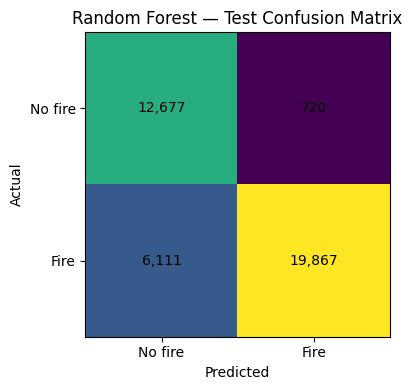

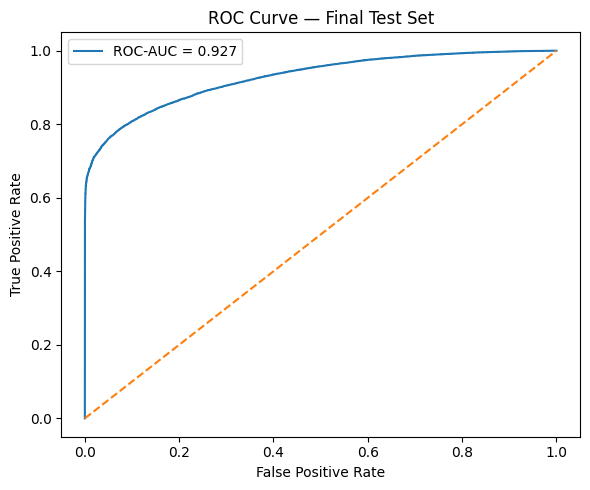

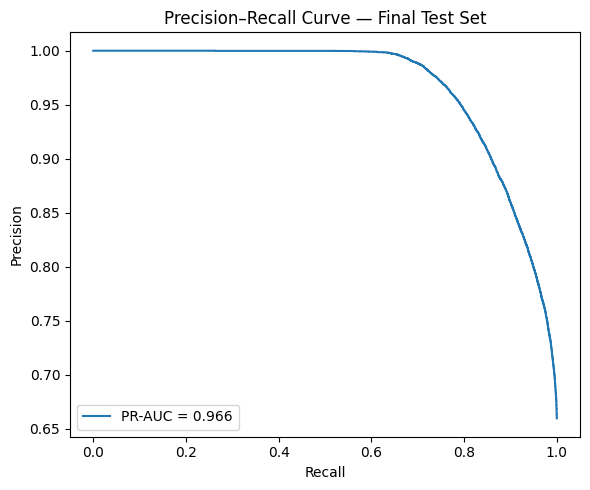

In [12]:
test_pred = (test_scores >= best_threshold).astype(int)
cm = confusion_matrix(y_test, test_pred)

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm)
for (i, j), value in np.ndenumerate(cm):
    ax.text(j, i, f'{value:,}', ha='center', va='center')
ax.set_xticks([0, 1], ['No fire', 'Fire'])
ax.set_yticks([0, 1], ['No fire', 'Fire'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'{best_name} — Test Confusion Matrix')
plt.tight_layout()
plt.savefig(OUT_DIR / 'confusion_matrix.png', dpi=180)
plt.show()

fpr, tpr, _ = roc_curve(y_test, test_scores)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_score(y_test, test_scores):.3f}')
ax.plot([0, 1], [0, 1], linestyle='--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Final Test Set')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'roc_curve.png', dpi=180)
plt.show()

precision, recall, _ = precision_recall_curve(y_test, test_scores)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(recall, precision, label=f'PR-AUC = {average_precision_score(y_test, test_scores):.3f}')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision–Recall Curve — Final Test Set')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'precision_recall_curve.png', dpi=180)
plt.show()


## 12. Feature importance

For tree-based models, feature importance helps explain which weather and engineered variables are contributing most strongly to the predictions. Importance indicates predictive usefulness, not causation.

In [ ]:
if hasattr(best_model, 'feature_importances_'):
    importance = pd.DataFrame({
        'feature': FEATURES,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)

    display(importance.head(15))
    importance.to_csv(OUT_DIR / 'feature_importance.csv', index=False)

    top = importance.head(15).sort_values('importance')
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(top['feature'], top['importance'])
    ax.set_xlabel('Importance')
    ax.set_title(f'{best_name} — Top Feature Importance')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'feature_importance.png', dpi=180)
    plt.show()
else:
    print('Native feature importance is not available for the selected model.')


## 13. Save test predictions

Saving row-level scores is useful for the dashboard integration and for checking where false positives/false negatives occur.

In [13]:
prediction_output = df.loc[X_test.index, ['acq_date', 'lat_round', 'lon_round', 'label']].copy()
prediction_output['fire_risk_score'] = test_scores
prediction_output['fire_risk_percent'] = 100 * test_scores
prediction_output['predicted_label'] = test_pred

prediction_output.to_csv(OUT_DIR / 'test_predictions.csv', index=False)
display(prediction_output.head(10))


,acq_date,lat_round,lon_round,label,fire_risk_score,fire_risk_percent,predicted_label
60742,2026-03-30,-30.0,148.5,1,0.511245,51.124499,0
205562,2024-11-15,-12.0,134.0,0,0.371541,37.154138,0
130826,2024-11-01,-19.5,128.0,1,0.972320,97.231954,1
146325,2024-10-09,-18.0,145.5,1,0.472646,47.264581,0
68712,2025-05-04,-28.5,114.5,0,0.213057,21.305710,0
10925,2024-05-01,-37.0,150.0,0,0.178800,17.879991,0
109719,2026-06-20,-22.5,117.0,0,0.294254,29.425416,0
113876,2025-10-20,-22.0,120.5,1,0.728981,72.898062,1
141038,2025-12-15,-18.5,140.5,1,0.361148,36.114763,0
75648,2025-01-11,-27.5,149.0,0,0.178581,17.858138,0


## 14. Train the production model and save the model bundle

After the final test metrics have been recorded, the chosen model configuration is refitted on all available labelled data for deployment. The previously selected threshold is retained.

The saved bundle contains the model, feature order and threshold so the backend can reproduce exactly the same input structure.

In [14]:
production_model = clone(models[best_name])
production_model.fit(X, y)

model_bundle = {
    'model': production_model,
    'model_name': best_name,
    'threshold': best_threshold,
    'features': FEATURES,
    'target': 'label',
    'target_definition': '1 = fire occurrence / qualifying detection; 0 = sampled no-fire day',
    'score_note': 'predict_proba output is a model fire-risk score; validate calibration before treating it as a literal real-world probability'
}

model_path = OUT_DIR / 'fire_occurrence_model.pkl'
joblib.dump(model_bundle, model_path)
print('Saved:', model_path)


Saved: /content/drive/MyDrive/fire_model_outputs/fire_occurrence_model.pkl


## 15. Live prediction helper

The live pipeline should provide the same weather and engineered inputs used during training. This helper creates the cyclical date/wind variables and returns both the risk score and binary result.

In [15]:
def prepare_live_features(live_df):
    live = live_df.copy()
    live['acq_date'] = pd.to_datetime(live['acq_date'])

    live['day_of_year'] = live['acq_date'].dt.dayofyear
    live['month'] = live['acq_date'].dt.month
    live['day_of_year_sin'] = np.sin(2 * np.pi * live['day_of_year'] / 365.25)
    live['day_of_year_cos'] = np.cos(2 * np.pi * live['day_of_year'] / 365.25)
    live['month_sin'] = np.sin(2 * np.pi * live['month'] / 12)
    live['month_cos'] = np.cos(2 * np.pi * live['month'] / 12)

    wind_rad = np.deg2rad(live['wind_direction_10m'])
    live['wind_direction_sin'] = np.sin(wind_rad)
    live['wind_direction_cos'] = np.cos(wind_rad)

    missing = [c for c in FEATURES if c not in live.columns]
    assert not missing, f'Live input is missing required features: {missing}'
    return live[FEATURES]


def predict_fire_occurrence(live_df, bundle=model_bundle):
    live_X = prepare_live_features(live_df)
    scores = bundle['model'].predict_proba(live_X)[:, 1]
    labels = (scores >= bundle['threshold']).astype(int)

    return pd.DataFrame({
        'fire_risk_score': scores,
        'fire_risk_percent': 100 * scores,
        'predicted_label': labels
    })


## 16. Interpretation and limitations

### How to interpret the final model

- **Precision**: when the model predicts fire, how often that prediction matches a positive historical label.
- **Recall**: how many positive fire-labelled cases the model successfully detects.
- **ROC-AUC**: how well the model ranks fire cases above no-fire cases across all thresholds.
- **PR-AUC**: especially useful when the class distribution is unequal.
- **Balanced accuracy**: gives equal importance to the fire and no-fire classes.

### Important limitations

1. `label = 0` means no qualifying detection was used for that sampled grid-cell/day; it is not field-confirmed proof that absolutely no fire existed.
2. The model learns statistical relationships from historical labelled data and should not be treated as an emergency-warning system without further operational validation.
3. FFDI/KBDI are engineered predictors; their quality depends on the weather history and assumptions used to calculate them.
4. The model fire-risk score is suitable for ranking/heatmap display, but probability calibration should be tested before presenting it as an exact real-world percentage chance of fire.
5. Performance should be monitored over time because weather patterns, class balance and data coverage can change.

## 17. Verified reference run on the current corrected dataset

Using the current corrected daily dataset generated from the full weather archive, a 60/20/20 stratified split and the Random Forest configuration in this notebook produced the following **reference** test results:

| Metric | Reference result |
|---|---:|
| Accuracy | 0.8644 |
| Balanced accuracy | 0.8516 |
| Precision (fire) | 0.9189 |
| Recall (fire) | 0.8839 |
| F1-score (fire) | 0.9010 |
| ROC-AUC | 0.9273 |
| PR-AUC | 0.9605 |

Validation-selected threshold: **0.6042**.

These values are a reproducibility check only. If `final_df` changes, rerun the notebook and use the newly generated outputs rather than copying these numbers.